# Week 1 hands-on: an autograd engine from scratch

*Generative AI from First Principles* · [course page](https://mathrulestheworld.github.io/genai-first-principles/)

Every model in this course is trained by gradient descent, and every gradient is computed by **reverse-mode automatic differentiation**. This notebook builds that machinery from scratch in about 300 lines of NumPy ([`tinylm/autograd.py`](../tinylm/autograd.py)) and uses it to train two classifiers.

1. A computation as a graph, and its gradient.
2. Why reverse mode is cheap: the gradient costs a constant multiple of the function.
3. Checking gradients against finite differences, and against PyTorch.
4. Logistic regression on a two-class problem.
5. A two-layer network on the same problem, and then on handwritten digits.

From Week 2 on we use PyTorch, whose autograd does exactly what this engine does, on GPUs and at scale. The point of this week is that nothing about it is magic.

In [1]:
import sys, time, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # use the repository's tinylm without installing it

import numpy as np
import matplotlib.pyplot as plt
from tinylm.autograd import Tensor, cross_entropy, binary_cross_entropy_with_logits, gradcheck, numerical_grad
from tinylm.nn import Linear, MLP
from tinylm.optim import SGD, Adam

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

## 1. A computation as a graph

Take $f(x, y) = \log(1 + e^{xy}) + x^2$. Each arithmetic step creates a new `Tensor` that remembers its inputs and how to pass a gradient back to them. Calling `backward()` on the output walks this graph from the output to the inputs.

In [2]:
x = Tensor(1.5, requires_grad=True)
y = Tensor(-0.5, requires_grad=True)
f = (1 + (x * y).exp()).log() + x ** 2
f.backward()

def show_graph(node, depth=0, seen=None):
    seen = set() if seen is None else seen
    label = node._op or ("x" if node is x else "y" if node is y else "const")
    print("  " * depth + f"{label:8s} value = {node.data: .4f}")
    if id(node) not in seen:
        seen.add(id(node))
        for p in node._parents:
            show_graph(p, depth + 1, seen)

show_graph(f)
s = 1 / (1 + np.exp(-x.data * y.data))                 # sigmoid(xy), the derivative of log(1 + e^t)
print(f"\nautograd:  df/dx = {x.grad:.6f}   df/dy = {y.grad:.6f}")
print(f"by hand:   df/dx = {s * y.data + 2 * x.data:.6f}   df/dy = {s * x.data:.6f}")

+        value =  2.6369
  log      value =  0.3869
    +        value =  1.4724
      exp      value =  0.4724
        *        value = -0.7500
          x        value =  1.5000
          y        value = -0.5000
      const    value =  1.0000
  **2      value =  2.2500
    x        value =  1.5000

autograd:  df/dx = 2.839589   df/dy = 0.481232
by hand:   df/dx = 2.839589   df/dy = 0.481232


## 2. Reverse mode is a sequence of vector–Jacobian products

Write a computation as $f = f_L \circ \cdots \circ f_1$ with a scalar output. By the chain rule its gradient is

$$\nabla f(x)^\top = J_L\, J_{L-1} \cdots J_1,$$

a product of Jacobians. Evaluating it from the left, starting from the $1\times 1$ output, only ever multiplies a *row vector* by a Jacobian: a **vector–Jacobian product**. Each step costs about as much as the forward operation it reverses. So the whole gradient, with respect to every one of possibly millions of inputs, costs a small constant multiple of computing $f$ once. This is the *cheap gradient principle*. In the model of arithmetic circuits it is a theorem of Baur and Strassen (1983): all partial derivatives of a function computed by a circuit of size $L$ can be computed by a circuit of size $O(L)$.

Finite differences, by contrast, need two evaluations of $f$ *per input*. The experiment below measures both on a two-layer network.

width    32:    2410 parameters, forward   0.20 ms, forward+backward   0.59 ms, ratio 2.9
width    64:    4810 parameters, forward   0.27 ms, forward+backward   0.80 ms, ratio 3.0
width   128:    9610 parameters, forward   0.39 ms, forward+backward   1.09 ms, ratio 2.8
width   256:   19210 parameters, forward   0.67 ms, forward+backward   2.42 ms, ratio 3.6
width   512:   38410 parameters, forward   3.23 ms, forward+backward   5.90 ms, ratio 1.8


width  1024:   76810 parameters, forward   5.90 ms, forward+backward  10.30 ms, ratio 1.7



For the width-1024 network, finite differences would need 153,620 forward passes, about 17 minutes; the loss and its full gradient together take 15 ms.


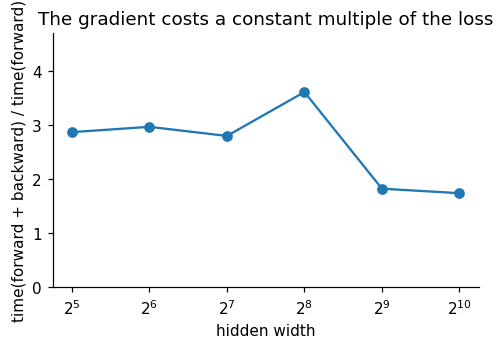

In [3]:
def loss_of_mlp(width, batch=256, d_in=64, classes=10, seed=0):
    r = np.random.default_rng(seed)
    X, labels = Tensor(r.normal(size=(batch, d_in))), r.integers(0, classes, size=batch)
    model = MLP([d_in, width, classes], rng=r)
    return model, (lambda: cross_entropy(model(X), labels))

def best_time(fn, repeats=5):
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter(); fn(); times.append(time.perf_counter() - t0)
    return min(times)

widths, ratios = [32, 64, 128, 256, 512, 1024], []
for w in widths:
    model, loss = loss_of_mlp(w)
    t_forward = best_time(loss)
    t_both = best_time(lambda: loss().backward())
    ratios.append(t_both / t_forward)
    print(f"width {w:5d}: {model.num_parameters():7d} parameters, forward {1e3*t_forward:6.2f} ms, "
          f"forward+backward {1e3*t_both:6.2f} ms, ratio {t_both / t_forward:.1f}")

model, loss = loss_of_mlp(1024)
n, t_f = model.num_parameters(), best_time(loss)
print(f"\nFor the width-1024 network, finite differences would need {2 * n:,} forward passes, "
      f"about {2 * n * t_f / 60:.0f} minutes; the loss and its full gradient together take {1e3 * best_time(lambda: loss().backward()):.0f} ms.")

plt.figure(figsize=(5, 3))
plt.plot(widths, ratios, "o-")
plt.xscale("log", base=2); plt.ylim(0, max(ratios) * 1.3)
plt.xlabel("hidden width"); plt.ylabel("time(forward + backward) / time(forward)")
plt.title("The gradient costs a constant multiple of the loss"); plt.show()

## 3. Checking gradients

A gradient implementation is easy to get subtly wrong, so every operation in the engine is checked against the **central difference**

$$\frac{\partial f}{\partial x_i} \approx \frac{f(x + h e_i) - f(x - h e_i)}{2h}.$$

Its error has two sources. Taylor expansion gives a truncation error of order $h^2$, while floating-point rounding in the two evaluations of $f$ contributes about $\varepsilon/h$, where $\varepsilon \approx 10^{-16}$ is machine precision. The total is smallest near $h \approx \varepsilon^{1/3} \approx 10^{-5}$, which is visible below.

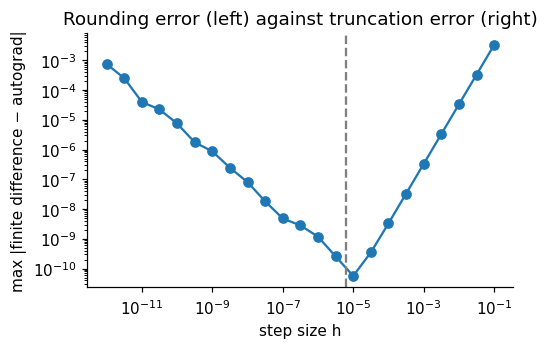

largest relative error, several operations:
  matmul + tanh          4.8e-10
  broadcast divide       9.0e-11
  softmax cross-entropy  2.3e-10
  reused tensor          1.2e-10


In [4]:
a = Tensor(rng.normal(size=(4, 3)), requires_grad=True)
g = lambda: (a.tanh() @ a.T).logsumexp(axis=-1).sum()
a.zero_grad(); g().backward()
exact = a.grad.copy()

hs = np.logspace(-12, -1, 23)
errors = [np.abs(numerical_grad(g, a, eps=h) - exact).max() for h in hs]
plt.figure(figsize=(5, 3))
plt.loglog(hs, errors, "o-")
plt.axvline(np.finfo(float).eps ** (1 / 3), ls="--", c="gray")
plt.xlabel("step size h"); plt.ylabel("max |finite difference − autograd|")
plt.title("Rounding error (left) against truncation error (right)"); plt.show()

print("largest relative error, several operations:")
b = Tensor(rng.normal(size=(3, 5)), requires_grad=True)
checks = {
    "matmul + tanh": lambda: (a @ b).tanh().sum(),
    "broadcast divide": lambda: (a / (b.sum(axis=1, keepdims=True).T ** 2 + 1.0)).sum(),
    "softmax cross-entropy": lambda: cross_entropy(a @ b, np.array([0, 4, 2, 1])),
    "reused tensor": lambda: (a * a * a).sum(),
}
for name, fn in checks.items():
    print(f"  {name:22s} {gradcheck(fn, [a, b]):.1e}")

In [5]:
try:
    import torch
    W = rng.normal(size=(5, 3)); X = rng.normal(size=(8, 5)); labels = rng.integers(0, 3, size=8)
    ours = Tensor(W, requires_grad=True)
    cross_entropy((Tensor(X) @ ours).tanh(), labels).backward()
    theirs = torch.tensor(W, requires_grad=True)
    torch.nn.functional.cross_entropy(torch.tanh(torch.tensor(X) @ theirs), torch.tensor(labels)).backward()
    print("largest difference from PyTorch's gradient:", np.abs(ours.grad - theirs.grad.numpy()).max())
except ImportError:
    print("PyTorch is not installed; skipping the comparison.")

largest difference from PyTorch's gradient: 2.7755575615628914e-17


## 4. Logistic regression

Now we train a model. The data are two interleaved half-moons in the plane, with labels $y \in \{0, 1\}$. Logistic regression predicts $\Pr(y = 1 \mid x) = \sigma(w^\top x + b)$ and is fitted by minimizing the average cross-entropy.

The data are split once into **training**, **validation**, and **test** sets. Only the training set is used for fitting, the validation set for choices such as the model size, and the test set once at the very end.

In [6]:
from sklearn.datasets import make_moons, load_digits

def split(X, y, seed=0, frac=(0.6, 0.2)):
    idx = np.random.default_rng(seed).permutation(len(X))
    a, b = int(frac[0] * len(X)), int((frac[0] + frac[1]) * len(X))
    return (X[idx[:a]], y[idx[:a]]), (X[idx[a:b]], y[idx[a:b]]), (X[idx[b:]], y[idx[b:]])

X, y = make_moons(n_samples=600, noise=0.2, random_state=0)
(Xtr, ytr), (Xva, yva), (Xte, yte) = split(X, y)

def train(model, Xtr, ytr, Xva, yva, steps=400, lr=0.05, loss_fn=cross_entropy):
    opt = Adam(model.parameters(), lr=lr)
    history = []
    for step in range(steps):
        loss = loss_fn(model(Tensor(Xtr)), ytr)
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 10 == 0 or step == steps - 1:
            history.append((step, loss.item(), loss_fn(model(Tensor(Xva)), yva).item()))
    return np.array(history)

def accuracy(model, X, y):
    out = model(Tensor(X)).data
    pred = (out[:, 0] > 0).astype(int) if out.shape[1] == 1 else out.argmax(axis=1)
    return (pred == y).mean()

bce = lambda logits, y: binary_cross_entropy_with_logits(logits.reshape(-1), y)
logreg = Linear(2, 1, rng=np.random.default_rng(0))
hist_lr = train(logreg, Xtr, ytr, Xva, yva, loss_fn=bce)
print(f"logistic regression: train accuracy {accuracy(logreg, Xtr, ytr):.3f}, validation accuracy {accuracy(logreg, Xva, yva):.3f}")

logistic regression: train accuracy 0.897, validation accuracy 0.850


## 5. A two-layer network

A linear classifier can only draw a straight boundary, and the moons are not linearly separable. A network with one hidden layer of `tanh` units, $x \mapsto W_2 \tanh(W_1 x + b_1) + b_2$, can bend it. The code is the same; only the model changes.

two-layer network:   train accuracy 0.989, validation accuracy 0.975


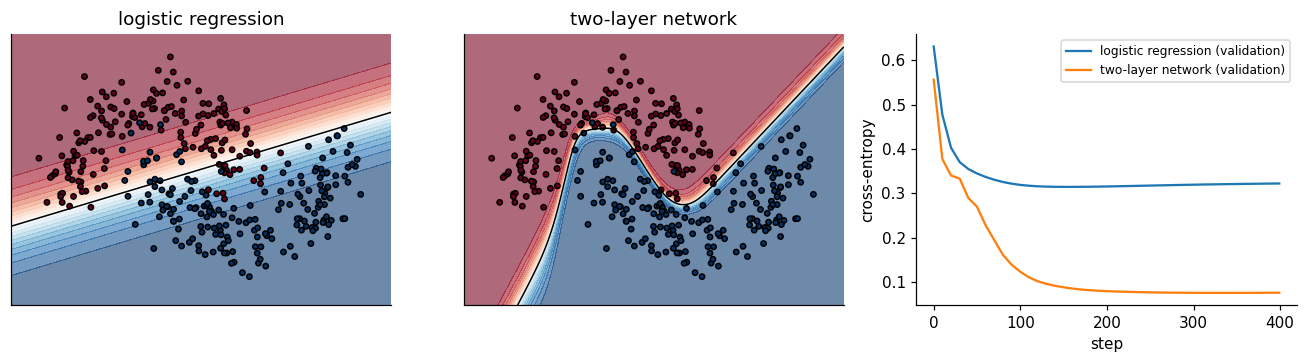

In [7]:
mlp = MLP([2, 16, 1], rng=np.random.default_rng(0))
hist_mlp = train(mlp, Xtr, ytr, Xva, yva, loss_fn=bce)
print(f"two-layer network:   train accuracy {accuracy(mlp, Xtr, ytr):.3f}, validation accuracy {accuracy(mlp, Xva, yva):.3f}")

xx, yy = np.meshgrid(np.linspace(-1.6, 2.6, 200), np.linspace(-1.2, 1.7, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, model, name in [(axes[0], logreg, "logistic regression"), (axes[1], mlp, "two-layer network")]:
    p = model(Tensor(grid)).sigmoid().data.reshape(xx.shape)
    ax.contourf(xx, yy, p, levels=20, cmap="RdBu", alpha=0.6)
    ax.contour(xx, yy, p, levels=[0.5], colors="k", linewidths=1)
    ax.scatter(*Xtr.T, c=ytr, cmap="RdBu", edgecolors="k", s=12)
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
for hist, name in [(hist_lr, "logistic regression"), (hist_mlp, "two-layer network")]:
    axes[2].plot(hist[:, 0], hist[:, 2], label=f"{name} (validation)")
axes[2].set_xlabel("step"); axes[2].set_ylabel("cross-entropy"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Handwritten digits

The same code trains a ten-class classifier on the $8\times 8$ digit images bundled with scikit-learn (1,797 images). The validation set chooses the hidden width; the test set is used once, for the chosen model.

In [8]:
digits = load_digits()
Xd, yd = digits.data / 16.0, digits.target
(Dtr, ltr), (Dva, lva), (Dte, lte) = split(Xd, yd)

results = {}
results["softmax regression"] = Linear(64, 10, rng=np.random.default_rng(0))
train(results["softmax regression"], Dtr, ltr, Dva, lva, steps=300)
for width in [16, 32, 64]:
    model = MLP([64, width, 10], rng=np.random.default_rng(0))
    train(model, Dtr, ltr, Dva, lva, steps=300)
    results[f"two-layer, width {width}"] = model

for name, model in results.items():
    print(f"{name:22s} {model.num_parameters():5d} parameters   "
          f"train {accuracy(model, Dtr, ltr):.3f}   validation {accuracy(model, Dva, lva):.3f}")

best = max(results, key=lambda k: accuracy(results[k], Dva, lva))
print(f"\nchosen on validation: {best}; test accuracy {accuracy(results[best], Dte, lte):.3f} (the only use of the test set)")

softmax regression       650 parameters   train 0.997   validation 0.972
two-layer, width 16     1210 parameters   train 1.000   validation 0.975
two-layer, width 32     2410 parameters   train 1.000   validation 0.981
two-layer, width 64     4810 parameters   train 1.000   validation 0.975

chosen on validation: two-layer, width 32; test accuracy 0.983 (the only use of the test set)


## What comes next

This engine is the first piece of `tinylm`, the codebase that grows into a small language model over the course. From Week 2 on, PyTorch's autograd takes over the same job, with the same interface (`requires_grad`, `backward()`, `.grad`, `zero_grad()`, `step()`), so that the models can grow.

## Exercises

1. **A new operation.** Add `softplus(x) = log(1 + e^x)` to `Tensor`, with its vector–Jacobian product, in a numerically stable form. Check it with `gradcheck`, including at $x = \pm 800$.
2. **Reuse.** Explain why `backward` must *add* the contributions arriving at a tensor that is used more than once. Which test in `tests/test_autograd.py` fails if the addition becomes an assignment?
3. **Forward mode.** Implement forward-mode differentiation for scalar functions with dual numbers $a + b\varepsilon$, $\varepsilon^2 = 0$. How many passes does it need for the gradient of a function of $n$ inputs, and when is forward mode the better choice?
4. **Memory.** Reverse mode must keep every intermediate value until the backward pass reaches it. Estimate the memory of the width-1024 network in Section 2, and describe a way to trade computation for memory.
5. **Data discipline.** What goes wrong if the hidden width is chosen by test accuracy instead of validation accuracy? Simulate it: train many models with random widths and seeds, and compare the best test accuracy with the test accuracy of the model chosen on validation.